# Reddit Sentiment and Stock Returns 

## Project Overview
This project examines whether retail investor sentiment expressed on Reddit is associated with short-term stock returns. Using posts r/investing and r/wallstreetbets subreddits, I extract ticker mentions, score sentiment using a lexical NLP model (VADER), aggregate sentiment at the weekly level, and merge it with weekly stock return data.

Rather than attempting to build a trading strategy, the goal of this project is to evaluate the informational content and limitations of social-media sentiment in financial contexts.

---

## Research Question
**Does sentiment expressed in Reddit investment discussions predict short-term stock returns, and what are the limitations of lexical sentiment models in this setting?**


In [10]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# NLP
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Finance data
import yfinance as yf

In [19]:
df = pd.read_csv("final_reddit_dataset.csv")
df.head()

,week_start,week_end,ticker,mean_sentiment,post_count,weekly_return
0,2025-10-14,2025-10-21,META,0.47670,1,0.033190
1,2025-10-21,2025-10-28,AMC,0.00000,1,-0.065744
2,2025-10-21,2025-10-28,AMD,0.17146,5,0.090913
3,2025-10-21,2025-10-28,AMZN,0.55095,4,0.022249
4,2025-10-21,2025-10-28,AVGO,-0.78200,1,0.056587


## Data Sources

- **Reddit posts** collected from r/wallstreetbets and r/investing over 12 weeks, beginning in 2025-10-14.
- **Sentiment scores** computed using VADER (Valence Aware Dictionary and sEntiment Reasoner) that are between -1 and +1 inclusive. This score represents a normalized metric that depicts the overall emotional intensity of a text from negative, neutral, to positive. 
- **Stock return data** pulled from Yahoo Finance using adjusted closing prices.

Sentiment is aggregated at the ticker–week level, and weekly stock returns are computed over the same 12-week (3 month) time window.


## Technical Implementation and Data Engineering

This project required building a reproducible data pipeline that integrates unstructured text data from Reddit with structured financial return data. 

### Reddit Data Collection

Posts were collected programmatically using Reddit’s API via the `praw` library. Rather than scraping arbitrary content, I restricted the analysis to a predefined universe of widely discussed ticker*, spanning large-cap technology firms, frequently traded equities, and major ETFs. This constraint limits false-positive ticker matches.

To ensure temporal consistency, posts were collected in weekly windows over a 12-week horizon, enabling construction of a ticker–week panel suitable for regression analysis.

---

### Ticker Extraction and Validation

Ticker symbols were extracted from post titles and text using regular expressions designed to capture standalone capitalized tokens (e.g., `$AAPL`, `TSLA`) while avoiding embedded strings. To further reduce noise, extracted candidates were filtered against:
- A hardcoded ticker universe
- An exclusion list of common all-caps terms (e.g., “CEO,” “GDP,” “YOLO”)

This approach balances recall and precision while minimizing false ticker attribution.

```python
def extract_tickers(text):
    candidates = TICKER_PATTERN.findall(text.upper())
    return list({
        c for c in candidates
        if c in TICKER_UNIVERSE and c not in EXCLUDE_WORDS
    })


<Axes: xlabel='mean_sentiment', ylabel='weekly_return'>

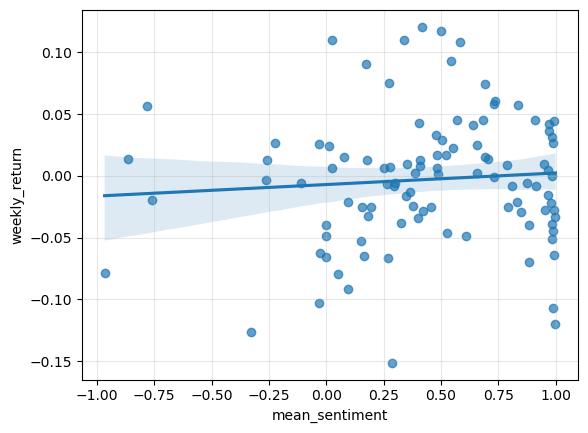

In [43]:
import seaborn as sns

x = pd.read_csv("final_reddit_dataset.csv")

plt.grid(alpha=0.3)
sns.regplot(x="mean_sentiment", y="weekly_return", data=x, scatter_kws={"alpha":0.7})

In [45]:
X = sm.add_constant(df["mean_sentiment"])
y = df["weekly_return"]

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          weekly_return   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.6399
Date:                Mon, 05 Jan 2026   Prob (F-statistic):              0.426
Time:                        14:58:06   Log-Likelihood:                 159.75
No. Observations:                 104   AIC:                            -315.5
Df Residuals:                     102   BIC:                            -310.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0071      0.007     -0.

## Results and Interpretation

The scatter plot and regression results indicate that Reddit sentiment has limited explanatory power for short-term stock returns. While some weeks show positive associations, the overall relationship is weak and unstable.

Given the p-value 0.426, **Reddit sentiment has no statistically meaningful relationship with short-term weekly stock returns in the sample**.

A key limitation is that lexical sentiment models such as VADER struggle to interpret financial sarcasm, memes, and norm-driven language common in Reddit investment communities. As a result, sentiment scores often misclassify tone and intent.

## Qualitative Analysis: Interpreting Reddit Sentiment Beyond Scores

To complement the quantitative sentiment–returns analysis, I conducted a qualitative examination of six Reddit posts sampled from r/wallstreetbets and r/investing (three from each).

The objective is not to replace quantitative sentiment analysis, but to clarify how linguistic, emotional, and cultural norms shape sentiment expression, and why automated sentiment models may systematically misinterpret tone in online investor communities.

---

## Coding and Thematic Categories

Through close reading, I identified five recurring themes that characterize how investors communicate about risk, performance, and uncertainty. These themes reflect not only linguistic patterns, but also the social identities and emotional norms of each subreddit.

Figure 3 below summarizes these themes.

### Figure 3: Qualitative Coding in r/wallstreetbets and r/investing

| Theme | Definition | Example Quote (r/wallstreetbets) | Example Quote (r/investing) | Interpretation / Contribution |
|------|------------|----------------------------------|------------------------------|-------------------------------|
| **Performance Flexing** | Displaying large financial gains to signal competence or status within the community | “+200k gain in a ROTH IRA” | N/A | r/wallstreetbets encourages performative displays of success, while r/investing avoids screenshot-based bragging. This contrast highlights heterogeneity in community norms and helps explain differences in sentiment expression across subreddits. |
| **YOLO & High-Risk Identity** | Embracing risky, speculative trading as a core identity; losses framed as part of belonging | “piss poor risk management with my INTC yolo but why else would I be here?” | N/A | r/wallstreetbets normalizes extreme risk-taking as a social signal, whereas r/investing emphasizes caution and fundamentals. Quantitative sentiment should therefore be interpreted relative to subreddit-specific norms. |
| **Post-Hoc Justification** | Rationalizing decisions after outcomes have already occurred | “When the market stabilizes everything will come back… which proved me right.” | “We were due for a bounce back after recent market declines.” | Demonstrates how even ostensibly neutral posts contain subtle positive framing, revealing why automated sentiment models may overestimate optimism. |
| **Emotional Resilience & Coping** | Using humor or metaphor to process financial loss and reframe it as a collective experience | “Lost over 5k… like a phoenix we rise from the ashes 🍻” | “I’m now crying so much because I must have incurred huge gains and will pay huge taxes.” | Negative experiences are often softened through humor or irony, which complicates the interpretation of negative sentiment scores. |
| **Community Knowledge & Collective Experience** | Invoking shared wisdom or group experience to justify or contextualize decisions | “everyone who experienced the panic selling should know…” | “Can someone tell me it will wash out in the long run?” | Highlights how posts rely on collective memory and reassurance, reinforcing group identity and underscoring heterogeneity across communities. |

---

## Implications for Sentiment Modeling

This qualitative analysis explains why lexical sentiment models such as **VADER may misclassify tone in financial subreddits. Expressions of risk, loss, or confidence are frequently embedded in community-specific humor, irony, and identity signaling**, which are difficult for automated models to interpret without contextual awareness.

As a result, sentiment scores should be interpreted cautiously alongside a qualitative understanding of the social environments.


## Conclusion

This project demonstrates that while social-media sentiment is an appealing data source, its practical use in financial prediction is constrained by linguistic and contextual challenges.

The results highlight the importance of model skepticism and judgment understanding not just how to apply analytical tools, but when their assumptions break down. Future work could explore domain-specific sentiment models or qualitative tagging to better capture investor narratives.
